In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Dense, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import cv2
from tqdm import tqdm
import os

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Load the training data
train_df = pd.read_csv('training.csv')
test_df = pd.read_csv('test.csv')
lookup_table = pd.read_csv('IdLookupTable.csv')

# Display basic info
print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)
print("\nTraining data columns:\n", train_df.columns)

# Check for missing values
print("\nMissing values in training data:\n", train_df.isnull().sum().sum())

Training data shape: (7049, 31)
Test data shape: (1783, 2)

Training data columns:
 Index(['left_eye_center_x', 'left_eye_center_y', 'right_eye_center_x',
       'right_eye_center_y', 'left_eye_inner_corner_x',
       'left_eye_inner_corner_y', 'left_eye_outer_corner_x',
       'left_eye_outer_corner_y', 'right_eye_inner_corner_x',
       'right_eye_inner_corner_y', 'right_eye_outer_corner_x',
       'right_eye_outer_corner_y', 'left_eyebrow_inner_end_x',
       'left_eyebrow_inner_end_y', 'left_eyebrow_outer_end_x',
       'left_eyebrow_outer_end_y', 'right_eyebrow_inner_end_x',
       'right_eyebrow_inner_end_y', 'right_eyebrow_outer_end_x',
       'right_eyebrow_outer_end_y', 'nose_tip_x', 'nose_tip_y',
       'mouth_left_corner_x', 'mouth_left_corner_y', 'mouth_right_corner_x',
       'mouth_right_corner_y', 'mouth_center_top_lip_x',
       'mouth_center_top_lip_y', 'mouth_center_bottom_lip_x',
       'mouth_center_bottom_lip_y', 'Image'],
      dtype='object')

Missing values in t

In [ ]:
# Fill missing values with the previous value in the column
train_df.fillna(method='ffill', inplace=True)

# Extract image arrays
def load_images(image_data):
    images = []
    for idx, img_str in enumerate(image_data['Image']):
        img = np.array(img_str.split(), dtype='float32')
        img = img.reshape(96, 96)
        images.append(img)
    return np.array(images)

# Extract keypoints (labels)
def extract_keypoints(df):
    keypoints = df.drop('Image', axis=1).values
    keypoints = keypoints.astype('float32')
    return keypoints

# Process the data
X_train = load_images(train_df)
y_train = extract_keypoints(train_df)

# Normalize images to [0, 1] range
X_train = X_train / 255.0

# Add channel dimension (for CNN)
X_train = X_train.reshape(-1, 96, 96, 1)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Validation data shape:", X_val.shape)

<ipython-input-5-3f42a12d1221>:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df.fillna(method='ffill', inplace=True)


Training data shape: (5639, 96, 96, 1)
Validation data shape: (1410, 96, 96, 1)


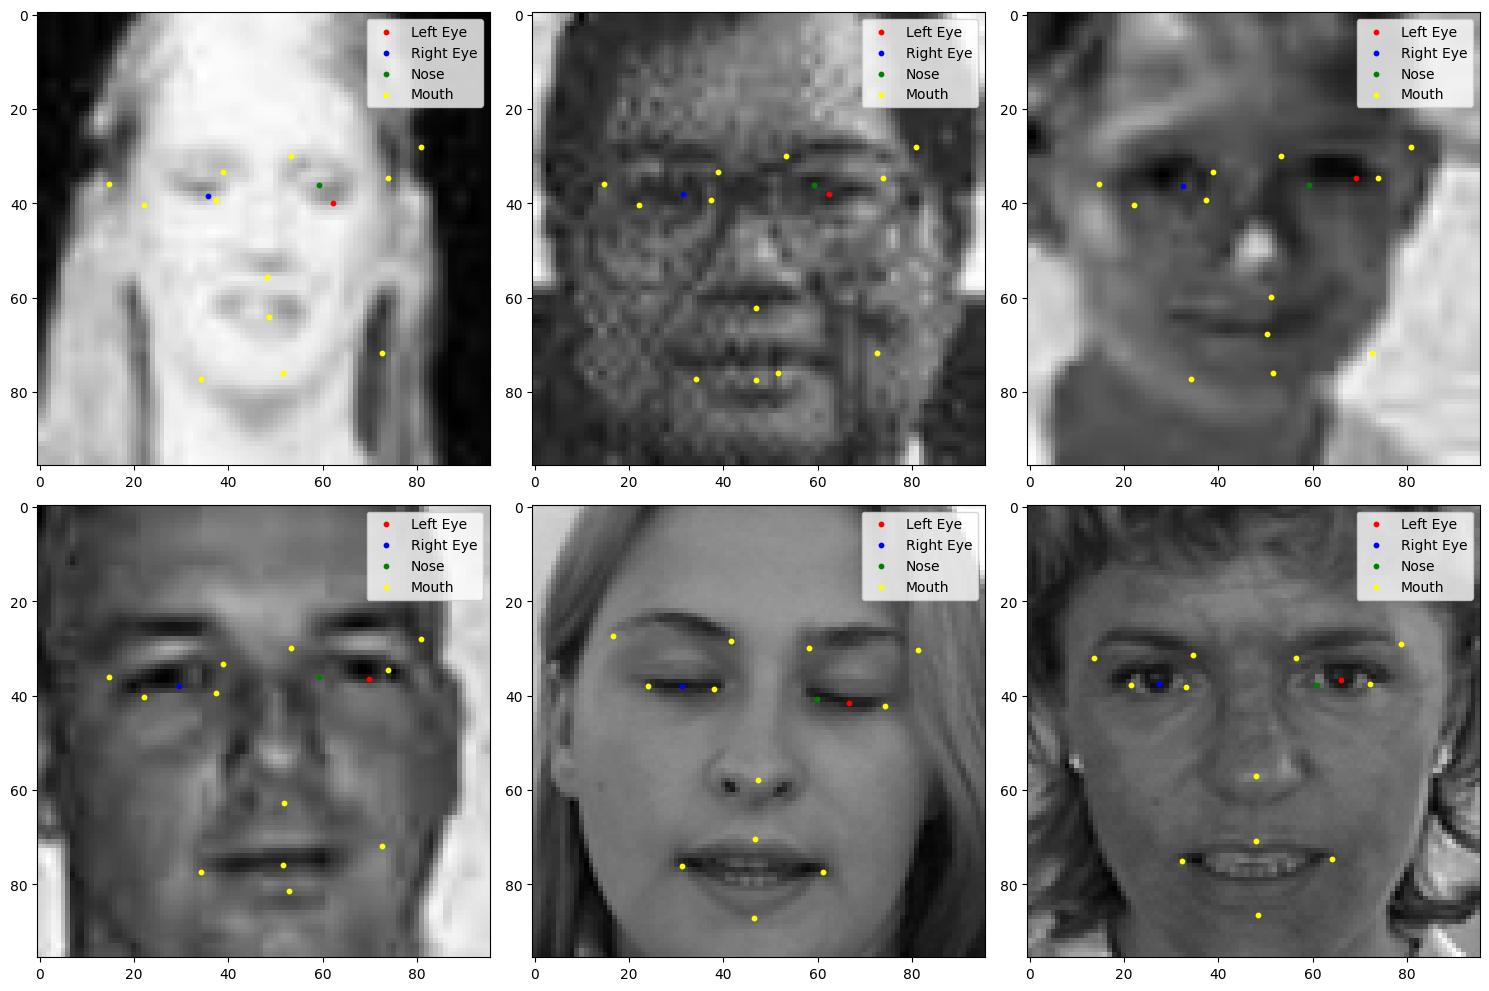

In [ ]:
# Function to plot sample images with keypoints
def plot_sample(image, keypoints, axis):
    image = image.reshape(96, 96)
    axis.imshow(image, cmap='gray')

    # Define colors for different facial parts
    # Left eye (indices 0-1)
    axis.scatter(keypoints[0], keypoints[1], c='red', label='Left Eye', s=10)
    # Right eye (indices 2-3)
    axis.scatter(keypoints[2], keypoints[3], c='blue', label='Right Eye', s=10)
    # Nose (indices 4-5)
    axis.scatter(keypoints[4], keypoints[5], c='green', label='Nose', s=10)
    # Mouth (indices 6-13)
    mouth_x = keypoints[6::2]
    mouth_y = keypoints[7::2]
    axis.scatter(mouth_x, mouth_y, c='yellow', label='Mouth', s=10)

# Plot some samples
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(X_train))
    plot_sample(X_train[idx], y_train[idx], ax)
    ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
def create_model():
    model = Sequential()

    # Input layer
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(96, 96, 1)))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Second block
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Third block
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Fourth block
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Flatten and dense layers
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    # Output layer - 30 values (15 keypoints x 2 coordinates)
    model.add(Dense(30))

    return model

model = create_model()
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 96, 96, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 96, 96, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 96, 96, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 96, 96, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 48, 48, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 48, 48, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 48, 48, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 48, 48, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 24, 24, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 24, 24, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 24, 24, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 6,036,734 (23.03 MB)

 Trainable params: 6,033,278 (23.02 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [ ]:
# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=20, min_lr=1e-6)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,  # Using large number of epochs with early stopping
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 40s 215ms/step - loss: 2670.6572 - mae: 48.1109 - val_loss: 2333.7515 - val_mae: 44.9582 - learning_rate: 0.0010
Epoch 2/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 2480.4741 - mae: 46.1265 - val_loss: 1994.7955 - val_mae: 38.3205 - learning_rate: 0.0010
Epoch 3/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 1751.8623 - mae: 37.4458 - val_loss: 822.9085 - val_mae: 23.6891 - learning_rate: 0.0010
Epoch 4/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 805.0996 - mae: 22.8322 - val_loss: 398.6179 - val_mae: 15.1223 - learning_rate: 0.0010
Epoch 5/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - loss: 276.7304 - mae: 11.9697 - val_loss: 87.2774 - val_mae: 6.4313 - learning_rate: 0.0010
Epoch 6/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 101.8956 - mae: 7.2698 - val_loss: 28.9004 - val_mae: 3.7514 - learning_rate: 0.0010
Epoch 7/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 57.3234 - mae: 5.4972 - val_loss: 13.2608 - val_

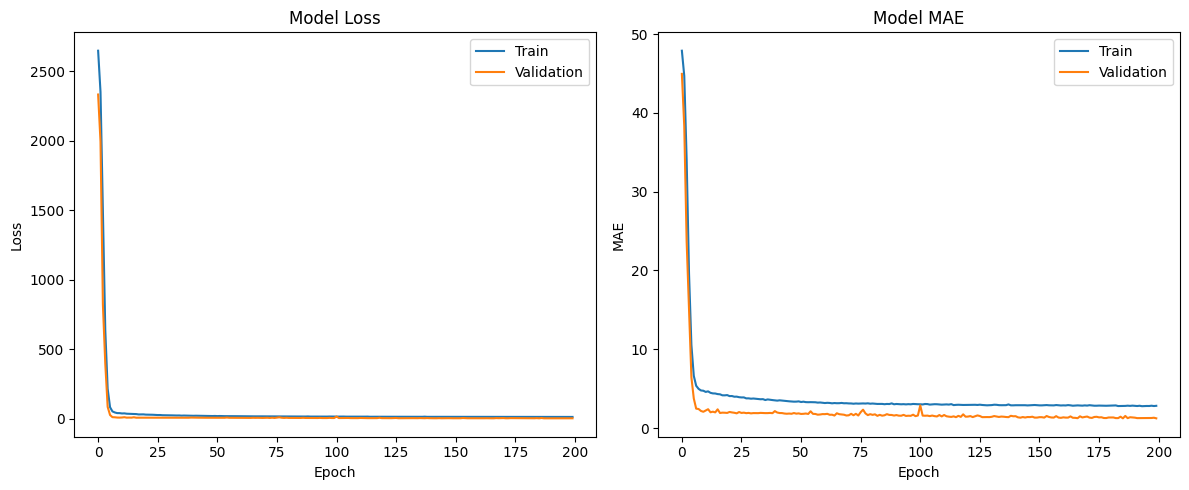

Validation Loss: 4.7237
Validation MAE: 1.2546


In [ ]:
# Plot training history
plt.figure(figsize=(12, 5))

# Plot training & validation loss values
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

# Plot training & validation MAE values
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('Model MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.tight_layout()
plt.show()

# Evaluate on validation set
val_loss, val_mae = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation MAE: {val_mae:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


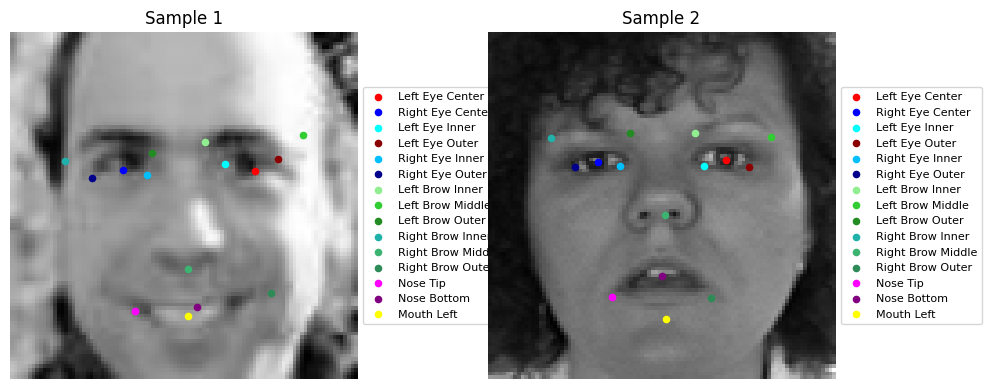

In [ ]:
def visualize_predictions(images, true_keypoints, pred_keypoints, num_samples=2):  # Changed to show 2 images
    plt.figure(figsize=(12, 6))  # Adjusted figure size for 2 images

    # Get random indices for samples to display
    indices = np.random.choice(range(len(images)), size=num_samples, replace=False)

    for i, idx in enumerate(indices):
        plt.subplot(1, 2, i+1)  # 1 row, 2 columns
        image = images[idx].reshape(96, 96)
        plt.imshow(image, cmap='gray')

        # Plot predicted keypoints with colors
        pred_kp = pred_keypoints[idx]

        # Define all facial landmarks with colors and labels
        landmarks = [
            # Eyes
            {'indices': [0, 1], 'color': 'red', 'label': 'Left Eye Center'},
            {'indices': [2, 3], 'color': 'blue', 'label': 'Right Eye Center'},
            {'indices': [4, 5], 'color': 'cyan', 'label': 'Left Eye Inner'},
            {'indices': [6, 7], 'color': 'darkred', 'label': 'Left Eye Outer'},
            {'indices': [8, 9], 'color': 'deepskyblue', 'label': 'Right Eye Inner'},
            {'indices': [10, 11], 'color': 'darkblue', 'label': 'Right Eye Outer'},

            # Eyebrows
            {'indices': [12, 13], 'color': 'lightgreen', 'label': 'Left Brow Inner'},
            {'indices': [14, 15], 'color': 'limegreen', 'label': 'Left Brow Middle'},
            {'indices': [16, 17], 'color': 'forestgreen', 'label': 'Left Brow Outer'},
            {'indices': [18, 19], 'color': 'lightseagreen', 'label': 'Right Brow Inner'},
            {'indices': [20, 21], 'color': 'mediumseagreen', 'label': 'Right Brow Middle'},
            {'indices': [22, 23], 'color': 'seagreen', 'label': 'Right Brow Outer'},

            # Nose
            {'indices': [24, 25], 'color': 'magenta', 'label': 'Nose Tip'},
            {'indices': [26, 27], 'color': 'purple', 'label': 'Nose Bottom'},

            # Mouth
            {'indices': [28, 29], 'color': 'yellow', 'label': 'Mouth Left'},
            {'indices': [30, 31], 'color': 'gold', 'label': 'Mouth Right'},
            {'indices': [32, 33], 'color': 'orange', 'label': 'Mouth Top'},
            {'indices': [34, 35], 'color': 'darkorange', 'label': 'Mouth Bottom'},
        ]

        # Plot each landmark
        for landmark in landmarks:
            x_idx, y_idx = landmark['indices']
            if x_idx < len(pred_kp) and y_idx < len(pred_kp):
                plt.scatter(pred_kp[x_idx], pred_kp[y_idx],
                           c=landmark['color'],
                           label=landmark['label'],
                           s=20)

        # Create a single legend for all points
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))

        # Place legend outside the plot on the right side
        plt.legend(by_label.values(), by_label.keys(),
                  loc='center left',
                  bbox_to_anchor=(1, 0.5),
                  prop={'size': 8})  # Smaller font size for legend

        plt.title(f"Sample {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(right=0.7)  # Make space for the legend
    plt.show()

# Visualize predictions (now shows only 2 images)
visualize_predictions(X_val, y_val, model.predict(X_val))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


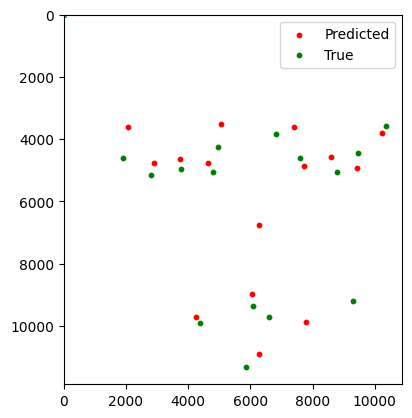

In [ ]:
#@title **👀 Detect & Visualize Keypoints**
def plot_keypoints(img, pred_kp, true_kp=None):
    img = (img * 255).astype('uint8')
    plt.imshow(img)

    # Reshape keypoints (x1,y1, x2,y2,...) into (N,2)
    pred_kp = pred_kp.reshape(-1, 2) * 128  # Scale back to image size

    # Plot predicted keypoints (red)
    plt.scatter(pred_kp[:,0], pred_kp[:,1], c='r', s=10, label='Predicted')

    # Plot true keypoints (green) if available
    if true_kp is not None:
        true_kp = true_kp.reshape(-1, 2) * 128
        plt.scatter(true_kp[:,0], true_kp[:,1], c='g', s=10, label='True')

    plt.legend()
    plt.show()

# Test on a sample image
sample_img = X_test[0]
sample_kp =y_val[0]
pred_kp = model.predict(sample_img[np.newaxis, ...])[0]

plot_keypoints(sample_img, pred_kp, sample_kp)